# RQ6 - External Validation and Distribution Shift

This consolidated RQ6 notebook replaces the older external-validation draft and the extended multi-dataset draft. It evaluates whether the HAM10000-trained ResNet50 model transfers to external skin-lesion datasets, whether confidence remains reliable under shift, and whether CAM explanations degrade or fail across datasets.

Run this after `00_setup_and_sanity.ipynb` and RQ1-RQ5. The final output files are consumed by `PAPER_RESULTS_TABLE.ipynb`.

In [25]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.stats import mannwhitneyu

NOTEBOOK_DIR = Path.cwd().resolve()
RESEARCH_DIR = NOTEBOOK_DIR.parent
BACKEND_DIR = Path(os.environ.get(
    "SKIN_LESION_BACKEND_DIR",
    RESEARCH_DIR.parent / "Skin_Lesion_Classification_backend",
)).resolve()
ML_DIR = BACKEND_DIR / "ml"
RAW_DIR = ML_DIR / "data" / "processed" / "raw"
METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"
OUT = NOTEBOOK_DIR / "outputs"
FIG_DIR = OUT / "figures"
METRICS_DIR = OUT / "metrics"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

SEED = 42
DATASET_SAMPLE_N = 200
XAI_SAMPLE_N = 30
DISAGREEMENT_SAMPLE_N = 20

print(f"Notebook: {NOTEBOOK_DIR}")
print(f"Backend:  {BACKEND_DIR}")
print(f"Raw data: {RAW_DIR}")
print(f"Model:    {MODEL_PATH}")

Notebook: C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks
Backend:  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend
Raw data: C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\data\processed\raw
Model:    C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\outputs\models\resnet50_best.pth


## CELL 1: Dataset Scanners

Each scanner returns a common schema: `image_id`, `filepath`, `true_label`, `diagnosis`, and `dataset`. Missing datasets are skipped with a clear warning so the notebook can run with whichever external datasets are available locally.

In [26]:
def _exists(path):
    return Path(path).exists()


def _standardize(df, dataset, id_col, label_col, diagnosis_col=None):
    out = pd.DataFrame({
        "image_id": df[id_col].astype(str),
        "filepath": df["filepath"].astype(str),
        "true_label": df[label_col].astype(int),
        "diagnosis": df[diagnosis_col].astype(str) if diagnosis_col and diagnosis_col in df else "unknown",
        "dataset": dataset,
    })
    out["exists"] = out["filepath"].apply(_exists)
    missing = int((~out["exists"]).sum())
    if missing:
        print(f"  WARNING: {dataset} has {missing} missing image paths; they will be dropped")
    out = out[out["exists"]].drop(columns=["exists"]).reset_index(drop=True)
    out = out[out["true_label"].isin([0, 1])].reset_index(drop=True)
    return out


def scan_ham10000():
    if not METADATA_PATH.exists():
        print(f"HAM10000 skipped: missing {METADATA_PATH}")
        return None
    df = pd.read_csv(METADATA_PATH)
    if "filepath" not in df:
        print("HAM10000 skipped: metadata has no filepath column")
        return None
    if "label" not in df:
        if "dx" in df:
            df["label"] = df["dx"].isin(["mel", "bcc", "akiec"]).astype(int)
        else:
            print("HAM10000 skipped: no label or dx column")
            return None
    if "image_id" not in df:
        df["image_id"] = df.index.astype(str)
    if "dx" not in df:
        df["dx"] = "unknown"
    out = _standardize(df, "HAM10000", "image_id", "label", "dx")
    print(f"HAM10000: {len(out)} valid images")
    return out


def scan_isic2020():
    meta_path = RAW_DIR / "isic2020" / "ISIC_2020_Training_MetaData.csv"
    img_dir = RAW_DIR / "isic2020" / "ISIC_2020_Training_JPEG" / "train"
    if not meta_path.exists() or not img_dir.exists():
        print("ISIC2020 skipped: metadata or image directory not found")
        return None
    df = pd.read_csv(meta_path)
    if "image_name" not in df or "target" not in df:
        print("ISIC2020 skipped: expected image_name and target columns")
        return None
    df["filepath"] = df["image_name"].apply(lambda x: str(img_dir / f"{x}.jpg"))
    if "benign_malignant" not in df:
        df["benign_malignant"] = df["target"].map({0: "benign", 1: "malignant"})
    out = _standardize(df, "ISIC2020", "image_name", "target", "benign_malignant")
    print(f"ISIC2020: {len(out)} valid images")
    return out


def scan_milk10k():
    meta_path = RAW_DIR / "milk10k" / "metadata.csv"
    img_dir = RAW_DIR / "milk10k" / "images"
    if not meta_path.exists() or not img_dir.exists():
        print("MILK10K skipped: metadata or image directory not found")
        return None
    df = pd.read_csv(meta_path)
    id_col = "isic_id" if "isic_id" in df else df.columns[0]
    diagnosis_col = "diagnosis_1" if "diagnosis_1" in df else None
    if diagnosis_col is None:
        print("MILK10K skipped: diagnosis_1 column not found")
        return None
    df["filepath"] = df[id_col].apply(lambda x: str(img_dir / f"{x}.jpg"))
    diag = df[diagnosis_col].astype(str).str.lower()
    df["true_label"] = np.where(diag.eq("malignant"), 1, np.where(diag.str.contains("benign"), 0, -1))
    out = _standardize(df, "MILK10K", id_col, "true_label", diagnosis_col)
    print(f"MILK10K: {len(out)} valid images")
    return out


def scan_malignant_benign():
    candidates = [
        RAW_DIR / "malignant-benign",
        RAW_DIR / "skin-cancer-dataset-malignant-and-benign",
        Path.home() / ".cache" / "kagglehub" / "datasets" / "vivekkumar2300" / "skin-cancer-dataset-malignant-and-benign" / "versions" / "1" / "35000 Dataset",
    ]
    root = next((p for p in candidates if p.exists()), None)
    if root is None:
        print("Malignant-Benign skipped: dataset directory not found")
        return None
    rows = []
    for img_path in root.rglob("*"):
        if not img_path.is_file() or img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        relative_text = " ".join(part.lower() for part in img_path.relative_to(root).parts)
        if "malignant" in relative_text:
            label, diagnosis = 1, "malignant"
        elif "benign" in relative_text:
            label, diagnosis = 0, "benign"
        else:
            continue
        rows.append({
            "image_id": img_path.stem,
            "filepath": str(img_path),
            "true_label": label,
            "diagnosis": diagnosis,
            "dataset": "Malignant-Benign",
        })
    if not rows:
        print("Malignant-Benign skipped: no labeled images found")
        return None
    out = pd.DataFrame(rows).drop_duplicates("filepath").reset_index(drop=True)
    print(f"Malignant-Benign: {len(out)} valid images")
    return out


def scan_ph2():
    root_candidates = [
        RAW_DIR / "ph2",
        RAW_DIR / "PH2",
        RAW_DIR / "ph2-dataset",
        Path.home() / ".cache" / "kagglehub" / "datasets" / "spacesurfer" / "ph2-dataset" / "versions" / "2",
    ]
    root = next((p for p in root_candidates if p.exists()), None)
    if root is None:
        print("PH2 skipped: dataset directory not found")
        return None
    label_path = root / "PH2Dataset" / "PH2_dataset.txt"
    image_root = root / "PH2Dataset" / "PH2 Dataset images"
    if label_path.exists() and image_root.exists():
        raw_labels = pd.read_csv(label_path, sep="|")
        labels = raw_labels[raw_labels["   Name "].str.contains("IMD", na=False)].copy()
        labels = labels.rename(columns={"   Name ": "image_id", " Clinical Diagnosis ": "clinical_dx"})
        labels["image_id"] = labels["image_id"].str.strip()
        labels["true_label"] = labels["clinical_dx"].map({0.0: 0, 1.0: 1, 2.0: 1})
        rows = []
        for _, row in labels.iterrows():
            derm_path = image_root / row["image_id"] / f"{row['image_id']}_Dermoscopic_Image" / f"{row['image_id']}.bmp"
            if derm_path.exists() and not pd.isna(row["true_label"]):
                label = int(row["true_label"])
                rows.append({"image_id": row["image_id"], "filepath": str(derm_path), "true_label": label, "diagnosis": "malignant" if label == 1 else "benign", "dataset": "PH2"})
        out = pd.DataFrame(rows).drop_duplicates("filepath").reset_index(drop=True)
        print(f"PH2: {len(out)} valid images")
        return out

    image_paths = [
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in {".bmp", ".jpg", ".jpeg", ".png"}
    ]
    rows = []
    for p in image_paths:
        low = str(p).lower()
        if "melanoma" in low or "malignant" in low:
            label, diagnosis = 1, "malignant"
        elif "common_nevus" in low or "atypical_nevus" in low or "benign" in low or "nevus" in low:
            label, diagnosis = 0, "benign"
        else:
            continue
        rows.append({"image_id": p.stem, "filepath": str(p), "true_label": label, "diagnosis": diagnosis, "dataset": "PH2"})
    if not rows:
        print("PH2 skipped: images found but labels could not be inferred from paths")
        return None
    out = pd.DataFrame(rows).drop_duplicates("filepath").reset_index(drop=True)
    print(f"PH2: {len(out)} valid images")
    return out


datasets = {}
for scanner in [scan_ham10000, scan_isic2020, scan_milk10k, scan_malignant_benign, scan_ph2]:
    df = scanner()
    if df is None or len(df) == 0:
        continue
    name = df["dataset"].iloc[0]
    if df["true_label"].nunique() < 2:
        print(f"{name} skipped: only one class available")
        continue
    datasets[name] = df

if "HAM10000" not in datasets:
    raise RuntimeError("HAM10000 is required as the internal reference dataset.")

print("\nAvailable datasets:")
for name, df in datasets.items():
    print(f"  {name:<18} n={len(df):>6} labels={df['true_label'].value_counts().to_dict()}")

HAM10000: 10015 valid images
ISIC2020: 33126 valid images
MILK10K: 10234 valid images
Malignant-Benign: 34993 valid images
PH2: 200 valid images

Available datasets:
  HAM10000           n= 10015 labels={0: 8388, 1: 1627}
  ISIC2020           n= 33126 labels={0: 32542, 1: 584}
  MILK10K            n= 10234 labels={1: 7268, 0: 2966}
  Malignant-Benign   n= 34993 labels={0: 17500, 1: 17493}
  PH2                n=   200 labels={1: 120, 0: 80}


## CELL 2: Load Model

In [27]:
import torch

from src.models.classifier import create_model, get_target_layer
from src.data.dataset import get_transforms

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model = create_model("resnet50", num_classes=1).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

target_layer = get_target_layer(model, "resnet50")
transform = get_transforms("test", 224)
print("ResNet50 model loaded for RQ6.")

Device: cuda
ResNet50 model loaded for RQ6.


C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(name="to_tensor", image=lambda x, **kwargs: ToTensorV2()(image=x)["image"]),


## CELL 3: Evaluate Each Dataset Separately

The internal reference is HAM10000. External datasets are evaluated with the same model and fixed stratified sampling so results are reproducible.

In [28]:
def stratified_sample(df, sample_n=None, seed=SEED):
    df = df.reset_index(drop=True)
    if sample_n is None or len(df) <= sample_n:
        return df.copy()
    if df["true_label"].nunique() < 2:
        return df.sample(min(sample_n, len(df)), random_state=seed).reset_index(drop=True)
    sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_n, random_state=seed)
    _, sample_idx = next(sss.split(df, df["true_label"]))
    return df.iloc[sample_idx].reset_index(drop=True)

In [29]:
def evaluate_dataset(df, name, sample_n=DATASET_SAMPLE_N):
    sample = stratified_sample(df, sample_n=min(sample_n, len(df)))
    rows = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f"Evaluate {name}"):
        try:
            img = np.array(Image.open(row["filepath"]).convert("RGB").resize((224, 224)))
            inp = transform(image=img)["image"].unsqueeze(0).to(device)
            with torch.no_grad():
                malignant_prob = float(torch.sigmoid(model(inp)[0, 0]).item())
            pred = int(malignant_prob > 0.5)
            confidence = malignant_prob if pred == 1 else 1.0 - malignant_prob
            rows.append({
                "dataset": name,
                "image_id": row["image_id"],
                "filepath": row["filepath"],
                "diagnosis": row.get("diagnosis", "unknown"),
                "true_label": int(row["true_label"]),
                "pred": pred,
                "malignant_prob": malignant_prob,
                "confidence": confidence,
                "correct": int(pred == int(row["true_label"])),
            })
        except Exception as exc:
            print(f"  ERROR evaluate [{name}] {row.get('image_id', '?')}: {exc}")
    return pd.DataFrame(rows)


all_results = {}
for name, df in datasets.items():
    res = evaluate_dataset(df, name)
    if len(res) == 0:
        print(f"{name}: no successful inference rows; skipping")
        continue
    all_results[name] = res
    auc = roc_auc_score(res["true_label"], res["malignant_prob"]) if res["true_label"].nunique() > 1 else np.nan
    acc = accuracy_score(res["true_label"], res["pred"])
    print(f"{name}: n={len(res)} AUC={auc:.4f} Acc={acc:.4f} Conf={res['confidence'].mean():.4f}")

if "HAM10000" not in all_results:
    raise RuntimeError("HAM10000 inference results are required before RQ6 performance analysis.")

ham_auc = roc_auc_score(all_results["HAM10000"]["true_label"], all_results["HAM10000"]["malignant_prob"])
print(f"Internal HAM10000 reference AUC: {ham_auc:.4f}")

Evaluate HAM10000: 100%|██████████| 9815/9815 [04:15<00:00, 38.46it/s]


HAM10000: n=9815 AUC=0.9479 Acc=0.8699 Conf=0.8963


Evaluate ISIC2020: 100%|██████████| 32926/32926 [1:32:03<00:00,  5.96it/s]


ISIC2020: n=32926 AUC=0.6348 Acc=0.9126 Conf=0.8936


Evaluate MILK10K: 100%|██████████| 10034/10034 [03:27<00:00, 48.30it/s]


MILK10K: n=10034 AUC=0.6677 Acc=0.4202 Conf=0.8625


Evaluate Malignant-Benign: 100%|██████████| 34793/34793 [22:14<00:00, 26.07it/s]


Malignant-Benign: n=34793 AUC=0.7799 Acc=0.6489 Conf=0.8655


Evaluate PH2: 100%|██████████| 200/200 [00:04<00:00, 42.42it/s]

PH2: n=200 AUC=0.7450 Acc=0.5150 Conf=0.9266
Internal HAM10000 reference AUC: 0.9479


## CELL 4: Performance and Calibration Summary

=== RQ6 Separate Dataset Performance ===
         dataset     n    auc  accuracy  mean_confidence  brier_score  auc_drop_from_ham10000  benign_accuracy  malignant_accuracy
        HAM10000  9815 0.9479    0.8699           0.8963       0.0917                  0.0000           0.8676              0.8815
        ISIC2020 32926 0.6348    0.9126           0.8936       0.0704                  0.3131           0.9245              0.2483
         MILK10K 10034 0.6677    0.4202           0.8625       0.4598                  0.2802           0.9219              0.2154
Malignant-Benign 34793 0.7799    0.6489           0.8655       0.2671                  0.1681           0.9268              0.3708
             PH2   200 0.7450    0.5150           0.9266       0.4217                  0.2029           0.9875              0.2000


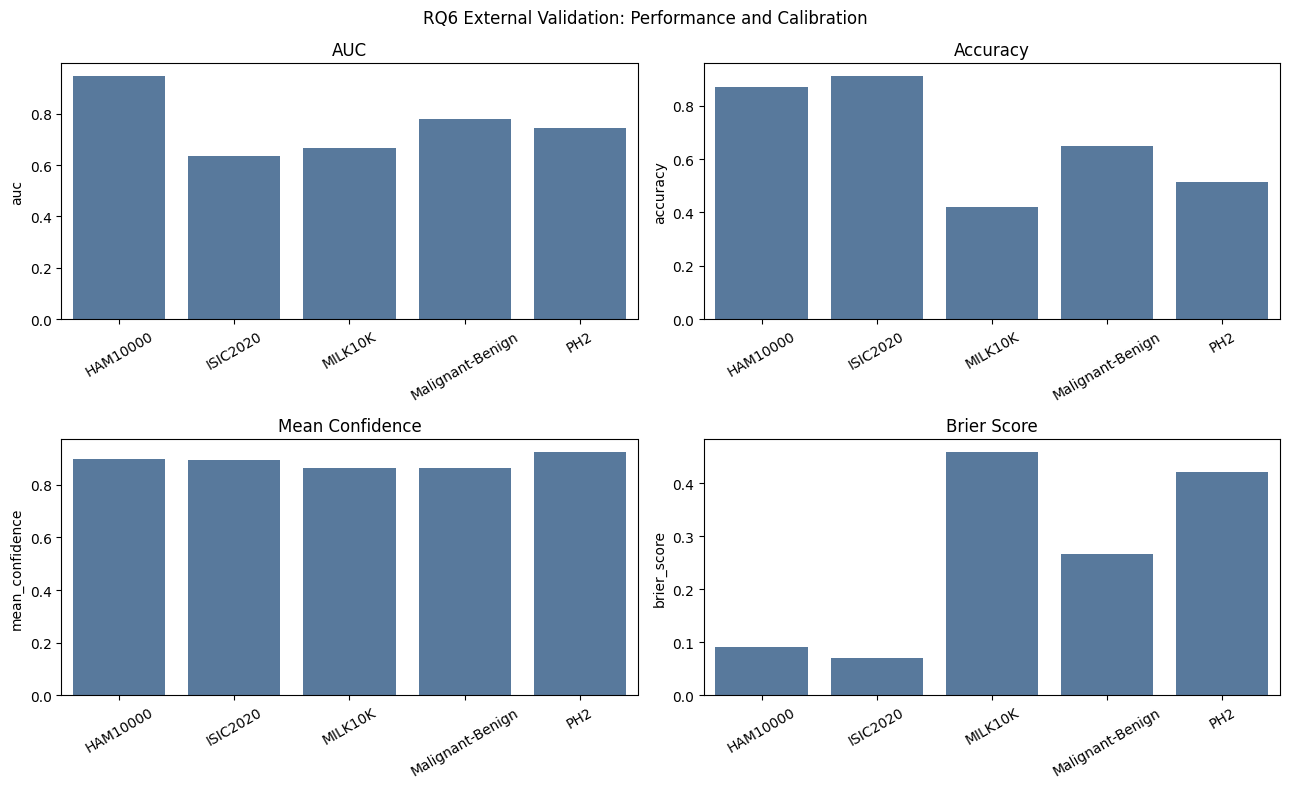

In [30]:
def safe_auc(df):
    if len(df) == 0 or df["true_label"].nunique() < 2:
        return np.nan
    return roc_auc_score(df["true_label"], df["malignant_prob"])


def class_accuracy(df, label):
    sub = df[df["true_label"] == label]
    if len(sub) == 0:
        return np.nan
    return accuracy_score(sub["true_label"], sub["pred"])


perf_rows = []
for name, res in all_results.items():
    auc = safe_auc(res)
    acc = accuracy_score(res["true_label"], res["pred"])
    brier = brier_score_loss(res["true_label"], res["malignant_prob"])
    perf_rows.append({
        "dataset": name,
        "n": len(res),
        "auc": auc,
        "accuracy": acc,
        "mean_confidence": res["confidence"].mean(),
        "brier_score": brier,
        "auc_drop_from_ham10000": ham_auc - auc if not np.isnan(auc) else np.nan,
        "benign_accuracy": class_accuracy(res, 0),
        "malignant_accuracy": class_accuracy(res, 1),
    })

perf_df = pd.DataFrame(perf_rows).sort_values("dataset").reset_index(drop=True)
print("=== RQ6 Separate Dataset Performance ===")
print(perf_df.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_order = perf_df["dataset"].tolist()
for ax, metric, title in [
    (axes[0, 0], "auc", "AUC"),
    (axes[0, 1], "accuracy", "Accuracy"),
    (axes[1, 0], "mean_confidence", "Mean Confidence"),
    (axes[1, 1], "brier_score", "Brier Score"),
]:
    sns.barplot(data=perf_df, x="dataset", y=metric, order=plot_order, ax=ax, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("RQ6 External Validation: Performance and Calibration")
plt.tight_layout()
plt.savefig(FIG_DIR / "RQ6_dataset_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## CELL 5: Extended Scenarios Stay Separate

The combined Top-3, dermoscopy-only, and All-5 stress tests remain in `RQ6_extended_datasets.ipynb` so this canonical RQ6 notebook stays short enough to rerun before the paper table. `PAPER_RESULTS_TABLE.ipynb` will load combined-scenario CSVs if the extended notebook has generated them, but it does not require them.

In [31]:
combined_df = pd.DataFrame()
print("Combined scenario analysis is kept in RQ6_extended_datasets.ipynb.")
print("Continue this notebook for core RQ6: separate external validation, calibration, XAI robustness, and CAM agreement.")

Combined scenario analysis is kept in RQ6_extended_datasets.ipynb.
Continue this notebook for core RQ6: separate external validation, calibration, XAI robustness, and CAM agreement.


## CELL 6: GradCAM Metrics and Zero-CAM Quality Check

Zero CAMs are tracked as an explanation failure mode. They are excluded from primary XAI means but reported explicitly.

In [32]:
import torch
from torch.cuda.amp import autocast
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

torch.backends.cudnn.benchmark = True

def focus_area_percentage(cam, threshold=0.5):
    return float((cam >= threshold).sum() / cam.size)


def attention_entropy(cam):
    flat = cam.astype(float).flatten()
    total = flat.sum()
    if total <= 1e-12:
        return 0.0
    prob = flat / total
    return float(-np.sum(prob * np.log(prob + 1e-12)))


def compute_gradcam_batch(filepaths, batch_size=16):
    tensors = []
    for p in filepaths:
        img = np.array(Image.open(p).convert("RGB").resize((224, 224)))
        tensors.append(transform(image=img)["image"])
    all_cams = []
    for i in range(0, len(tensors), batch_size):
        batch = torch.stack(tensors[i:i+batch_size]).to(device)
        with autocast(), GradCAM(model=model, target_layers=[target_layer]) as cam_model:
            cams = cam_model(input_tensor=batch, targets=[ClassifierOutputTarget(0)])
        all_cams.extend(cams)
    return all_cams


def compute_xai_for_results(res_df, name, n_sample=XAI_SAMPLE_N, batch_size=16, checkpoint_every=None):
    sample = stratified_sample(res_df, sample_n=min(n_sample, len(res_df)))
    rows = []
    total = len(sample)
    for i in range(0, total, batch_size):
        batch_sample = sample.iloc[i:i+batch_size]
        batch_paths = batch_sample["filepath"].tolist()
        try:
            cams = compute_gradcam_batch(batch_paths, batch_size=batch_size)
            for j, cam in enumerate(cams):
                row = batch_sample.iloc[j]
                cam_max = float(np.max(cam))
                rows.append({
                    "dataset": name,
                    "image_id": row["image_id"],
                    "true_label": int(row["true_label"]),
                    "pred": int(row["pred"]),
                    "correct": int(row["correct"]),
                    "confidence": float(row["confidence"]),
                    "fap_05": focus_area_percentage(cam, 0.5),
                    "entropy": attention_entropy(cam),
                    "cam_max": cam_max,
                    "zero_cam": int(cam_max <= 1e-8),
                })
        except Exception as exc:
            print(f"  ERROR XAI [{name}] batch {i}: {exc}")
        if checkpoint_every and (i + batch_size) % checkpoint_every == 0:
            intermediate = pd.DataFrame(rows)
            intermediate.to_csv(METRICS_DIR / f"RQ6_xai_{name}_checkpoint.csv", index=False)
            print(f"  [{name}] checkpoint at {len(rows)}/{total}")
    return pd.DataFrame(rows)


xai_frames = []
for name, res in all_results.items():
    print(f"Processing XAI for {name}...")
    xai = compute_xai_for_results(res, name, n_sample=XAI_SAMPLE_N, batch_size=16)
    xai_frames.append(xai)
    zero_count = int(xai["zero_cam"].sum()) if len(xai) else 0
    print(f"{name}: XAI rows={len(xai)}, zero CAMs={zero_count}")

xai_df = pd.concat(xai_frames, ignore_index=True) if xai_frames else pd.DataFrame()
valid_xai_df = xai_df[xai_df["zero_cam"] == 0].copy()

xai_summary = valid_xai_df.groupby("dataset").agg(
    n_valid=("image_id", "count"),
    fap_05_mean=("fap_05", "mean"),
    entropy_mean=("entropy", "mean"),
    confidence_mean=("confidence", "mean"),
    correct_rate=("correct", "mean"),
).reset_index()
zero_summary = xai_df.groupby("dataset").agg(
    n_xai=("image_id", "count"),
    zero_cam_count=("zero_cam", "sum"),
).reset_index()
xai_summary = zero_summary.merge(xai_summary, on="dataset", how="left")
xai_summary["zero_cam_rate"] = xai_summary["zero_cam_count"] / xai_summary["n_xai"]

print("=== RQ6 XAI Summary (zero CAMs excluded from means) ===")
print(xai_summary.round(4).to_string(index=False))

for _, row in xai_summary.iterrows():
    if row["zero_cam_count"] > 0:
        print(f"WARNING: {row['dataset']} has {int(row['zero_cam_count'])}/{int(row['n_xai'])} zero CAMs.")

Processing XAI for HAM10000...


C:\Users\saiyu\AppData\Local\Temp\ipykernel_13000\355086762.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(), GradCAM(model=model, target_layers=[target_layer]) as cam_model:


HAM10000: XAI rows=9785, zero CAMs=9274
Processing XAI for ISIC2020...


C:\Users\saiyu\AppData\Local\Temp\ipykernel_13000\355086762.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(), GradCAM(model=model, target_layers=[target_layer]) as cam_model:


ISIC2020: XAI rows=32896, zero CAMs=31026
Processing XAI for MILK10K...


...

MILK10K: XAI rows=10004, zero CAMs=9384
Processing XAI for Malignant-Benign...


C:\Users\saiyu\AppData\Local\Temp\ipykernel_13000\355086762.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(), GradCAM(model=model, target_layers=[target_layer]) as cam_model:


Malignant-Benign: XAI rows=34763, zero CAMs=32749
Processing XAI for PH2...


C:\Users\saiyu\AppData\Local\Temp\ipykernel_13000\355086762.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(), GradCAM(model=model, target_layers=[target_layer]) as cam_model:


PH2: XAI rows=170, zero CAMs=159
=== RQ6 XAI Summary (zero CAMs excluded from means) ===
         dataset  n_xai  zero_cam_count  n_valid  fap_05_mean  entropy_mean  confidence_mean  correct_rate  zero_cam_rate
        HAM10000   9785            9274      511       0.0573        9.2627           0.8690        0.8454         0.9478
        ISIC2020  32896           31026     1870       0.0517        9.3139           0.8799        0.9011         0.9432
         MILK10K  10004            9384      620       0.0533        9.3952           0.8582        0.4032         0.9380
Malignant-Benign  34763           32749     2014       0.0573        9.4743           0.8504        0.6137         0.9421
             PH2    170             159       11       0.0806        9.7395           0.9087        0.7273         0.9353


## CELL 7: XAI Visualization and Statistical Comparison

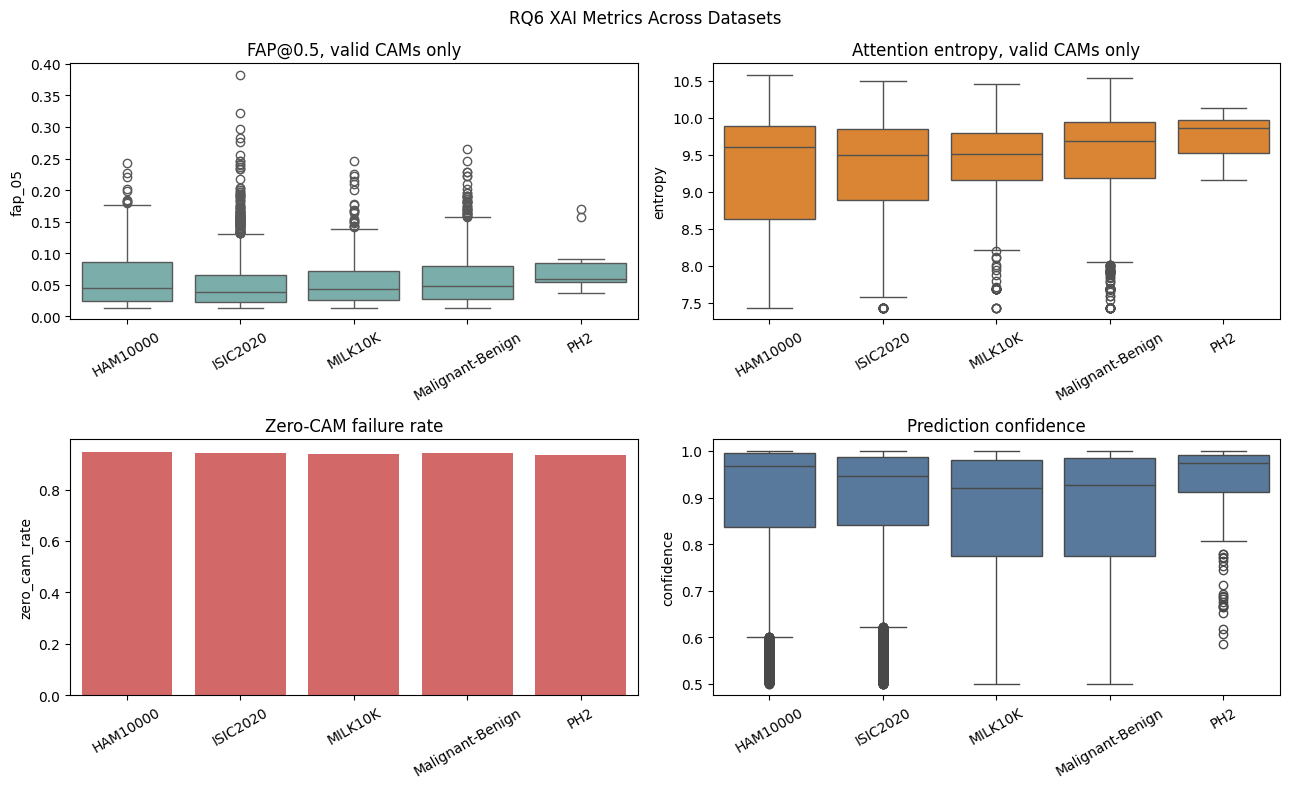

=== Mann-Whitney U tests vs HAM10000, valid CAMs only ===
fap_05: HAM10000=0.0573 vs ISIC2020=0.0517; p=0.0124
fap_05: HAM10000=0.0573 vs MILK10K=0.0533; p=0.6567
fap_05: HAM10000=0.0573 vs Malignant-Benign=0.0573; p=0.2100
fap_05: HAM10000=0.0573 vs PH2=0.0806; p=0.0329
entropy: HAM10000=9.2627 vs ISIC2020=9.3139; p=0.7470
entropy: HAM10000=9.2627 vs MILK10K=9.3952; p=0.8597
entropy: HAM10000=9.2627 vs Malignant-Benign=9.4743; p=0.0001
entropy: HAM10000=9.2627 vs PH2=9.7395; p=0.0715


In [33]:
if len(xai_df):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    order = sorted(xai_df["dataset"].unique())

    sns.boxplot(data=valid_xai_df, x="dataset", y="fap_05", order=order, ax=axes[0, 0], color="#72b7b2")
    axes[0, 0].set_title("FAP@0.5, valid CAMs only")
    sns.boxplot(data=valid_xai_df, x="dataset", y="entropy", order=order, ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("Attention entropy, valid CAMs only")
    sns.barplot(data=xai_summary, x="dataset", y="zero_cam_rate", order=order, ax=axes[1, 0], color="#e45756")
    axes[1, 0].set_title("Zero-CAM failure rate")
    sns.boxplot(data=xai_df, x="dataset", y="confidence", order=order, ax=axes[1, 1], color="#4c78a8")
    axes[1, 1].set_title("Prediction confidence")

    for ax in axes.flatten():
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)
    plt.suptitle("RQ6 XAI Metrics Across Datasets")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "RQ6_xai_all_datasets.png", dpi=160, bbox_inches="tight")
    plt.show()

    ham_valid = valid_xai_df[valid_xai_df["dataset"] == "HAM10000"]
    print("=== Mann-Whitney U tests vs HAM10000, valid CAMs only ===")
    for metric in ["fap_05", "entropy"]:
        for dataset_name in order:
            if dataset_name == "HAM10000":
                continue
            ext = valid_xai_df[valid_xai_df["dataset"] == dataset_name]
            if len(ham_valid) > 2 and len(ext) > 2:
                _, p_value = mannwhitneyu(ham_valid[metric], ext[metric], alternative="two-sided")
                print(f"{metric}: HAM10000={ham_valid[metric].mean():.4f} vs {dataset_name}={ext[metric].mean():.4f}; p={p_value:.4f}")
else:
    print("No XAI rows available.")

## CELL 8: Inter-Method CAM Agreement

High agreement is not automatically good. In this notebook it is treated as a descriptive robustness signal and interpreted alongside correctness and confidence.

Agreement PH2: 100%|██████████| 180/180 [01:12<00:00,  2.49it/s]


=== RQ6 Inter-Method Agreement Summary ===
         dataset     n  avg_jaccard_mean  min_jaccard_mean  max_jaccard_mean  correct_rate  confidence_mean
        HAM10000  9795            0.4651            0.1627            0.8912        0.8699           0.8963
        ISIC2020 32906            0.3813            0.0465            0.8737        0.9126           0.8936
         MILK10K 10014            0.4317            0.1075            0.8980        0.4198           0.8625
Malignant-Benign 34773            0.4501            0.1346            0.8974        0.6488           0.8655
             PH2   180            0.3868            0.0681            0.8826        0.5111           0.9277


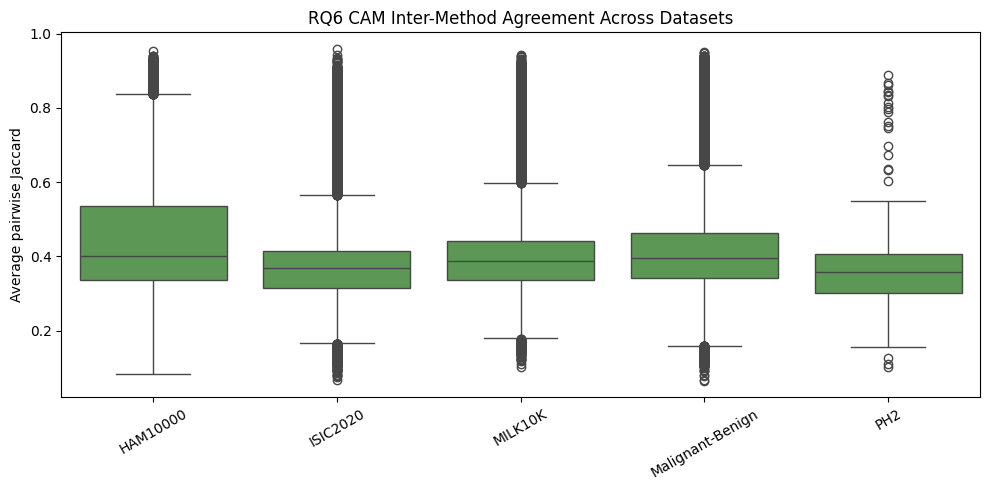

In [34]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM, LayerCAM

cam_methods = {
    "GradCAM": GradCAM,
    "GradCAM++": GradCAMPlusPlus,
    "EigenCAM": EigenCAM,
    "LayerCAM": LayerCAM,
}


def jaccard(cam_a, cam_b, threshold=0.5):
    a = cam_a >= threshold
    b = cam_b >= threshold
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 0.0
    return float(np.logical_and(a, b).sum() / union)


def compute_cam_set(filepath):
    img = np.array(Image.open(filepath).convert("RGB").resize((224, 224)))
    inp = transform(image=img)["image"].unsqueeze(0).to(device)
    cams = {}
    for method_name, method_cls in cam_methods.items():
        with method_cls(model=model, target_layers=[target_layer]) as cam_model:
            cams[method_name] = cam_model(input_tensor=inp, targets=[ClassifierOutputTarget(0)])[0]
    return cams


disc_rows = []
for name, res in all_results.items():
    sample = stratified_sample(res, sample_n=min(DISAGREEMENT_SAMPLE_N, len(res)))
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f"Agreement {name}"):
        try:
            cams = compute_cam_set(row["filepath"])
            method_names = list(cams.keys())
            pairs = []
            for i in range(len(method_names)):
                for j in range(i + 1, len(method_names)):
                    pairs.append(jaccard(cams[method_names[i]], cams[method_names[j]]))
            disc_rows.append({
                "dataset": name,
                "image_id": row["image_id"],
                "true_label": int(row["true_label"]),
                "pred": int(row["pred"]),
                "correct": int(row["correct"]),
                "confidence": float(row["confidence"]),
                "avg_jaccard": float(np.mean(pairs)),
                "min_jaccard": float(np.min(pairs)),
                "max_jaccard": float(np.max(pairs)),
            })
        except Exception as exc:
            print(f"  ERROR agreement [{name}] {row.get('image_id', '?')}: {exc}")

disc_df = pd.DataFrame(disc_rows)
if len(disc_df):
    disc_summary = disc_df.groupby("dataset").agg(
        n=("image_id", "count"),
        avg_jaccard_mean=("avg_jaccard", "mean"),
        min_jaccard_mean=("min_jaccard", "mean"),
        max_jaccard_mean=("max_jaccard", "mean"),
        correct_rate=("correct", "mean"),
        confidence_mean=("confidence", "mean"),
    ).reset_index()
    print("=== RQ6 Inter-Method Agreement Summary ===")
    print(disc_summary.round(4).to_string(index=False))

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=disc_df, x="dataset", y="avg_jaccard", order=sorted(disc_df["dataset"].unique()), color="#54a24b")
    plt.title("RQ6 CAM Inter-Method Agreement Across Datasets")
    plt.xlabel("")
    plt.ylabel("Average pairwise Jaccard")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "RQ6_disagreement_all_datasets.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    disc_summary = pd.DataFrame()
    print("No agreement rows available.")

## CELL 9: Save Canonical RQ6 Outputs

In [35]:
if "disc_df" not in globals():
    disc_df = pd.DataFrame(columns=["dataset", "image_id", "true_label", "pred", "correct", "confidence", "avg_jaccard", "min_jaccard", "max_jaccard"])
if "disc_summary" not in globals():
    disc_summary = pd.DataFrame(columns=["dataset", "n", "avg_jaccard_mean", "min_jaccard_mean", "max_jaccard_mean", "correct_rate", "confidence_mean"])

inference_df = pd.concat(all_results.values(), ignore_index=True) if "all_results" in globals() and all_results else pd.DataFrame()
inference_df.to_csv(METRICS_DIR / "RQ6_inference_all_datasets.csv", index=False)
perf_df.to_csv(METRICS_DIR / "RQ6_separate_performance.csv", index=False)
xai_df.to_csv(METRICS_DIR / "RQ6_xai_all_datasets.csv", index=False)
valid_xai_df.to_csv(METRICS_DIR / "RQ6_xai_valid_cams.csv", index=False)
xai_summary.to_csv(METRICS_DIR / "RQ6_xai_summary.csv", index=False)
disc_df.to_csv(METRICS_DIR / "RQ6_disagreement_all_datasets.csv", index=False)
disc_summary.to_csv(METRICS_DIR / "RQ6_disagreement_summary.csv", index=False)

print("Saved canonical RQ6 outputs:")
for path in [
    METRICS_DIR / "RQ6_inference_all_datasets.csv",
    METRICS_DIR / "RQ6_separate_performance.csv",
    METRICS_DIR / "RQ6_xai_all_datasets.csv",
    METRICS_DIR / "RQ6_xai_valid_cams.csv",
    METRICS_DIR / "RQ6_xai_summary.csv",
    METRICS_DIR / "RQ6_disagreement_all_datasets.csv",
    METRICS_DIR / "RQ6_disagreement_summary.csv",
]:
    print(f"  {path}")

Saved canonical RQ6 outputs:
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs\metrics\RQ6_inference_all_datasets.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs\metrics\RQ6_separate_performance.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs\metrics\RQ6_xai_all_datasets.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs\metrics\RQ6_xai_valid_cams.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs\metrics\RQ6_xai_summary.csv
  C:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks\outputs\metrics\RQ6_disagreement_all_datasets.csv
  C:\Users\saiyu\

In [36]:
# Rebuild all_results from saved CSVs (fast recovery without recomputing)
NOTEBOOK_DIR = Path.cwd().resolve()
OUT = NOTEBOOK_DIR / "outputs"
METRICS_DIR = OUT / "metrics"

import pandas as pd

inference_path = METRICS_DIR / "RQ6_inference_all_datasets.csv"
if not inference_path.exists():
    raise FileNotFoundError(f"Missing {inference_path}. Re-run the dataset evaluation cell before using cache recovery.")

inference_all = pd.read_csv(inference_path)
perf_df = pd.read_csv(METRICS_DIR / "RQ6_separate_performance.csv")
disc_df = pd.read_csv(METRICS_DIR / "RQ6_disagreement_all_datasets.csv")
xai_summary = pd.read_csv(METRICS_DIR / "RQ6_xai_summary.csv")
valid_xai_df = pd.read_csv(METRICS_DIR / "RQ6_xai_valid_cams.csv")
disc_summary = pd.read_csv(METRICS_DIR / "RQ6_disagreement_summary.csv")

all_results = {
    dataset_name: ds.reset_index(drop=True)
    for dataset_name, ds in inference_all.groupby("dataset", sort=False)
}

ham_auc = float(perf_df[perf_df["dataset"] == "HAM10000"]["auc"].values[0]) if "HAM10000" in perf_df["dataset"].values else 0.9479

print("Reconstructed from CSV cache:")
for name, res in all_results.items():
    print(f"  {name}: {len(res)} rows")

Reconstructed from CSV cache:
  HAM10000: 9815 rows
  ISIC2020: 32926 rows
  MILK10K: 10034 rows
  Malignant-Benign: 34793 rows
  PH2: 200 rows


In [37]:
import pandas as pd
if "disc_df" not in globals():
    disc_df = pd.DataFrame(columns=["dataset", "image_id", "true_label", "pred", "correct", "confidence", "avg_jaccard", "min_jaccard", "max_jaccard"])
if "disc_summary" not in globals():
    disc_summary = pd.DataFrame(columns=["dataset", "n", "avg_jaccard_mean", "min_jaccard_mean", "max_jaccard_mean", "correct_rate", "confidence_mean"])

print("=" * 88)
print("RQ6 SUMMARY - External Validation, Calibration, and XAI Robustness")
print("=" * 88)
print("\nSeparate dataset performance:")
print(perf_df.round(4).to_string(index=False))

print("\nXAI summary, with zero CAMs treated as explanation failures:")
print(xai_summary.round(4).to_string(index=False))

if len(disc_summary):
    print("\nInter-method CAM agreement:")
    print(disc_summary.round(4).to_string(index=False))

external_perf = perf_df[perf_df["dataset"] != "HAM10000"].copy()
if len(external_perf):
    worst_auc = external_perf.sort_values("auc", na_position="last").iloc[0]
    most_overconf = external_perf.sort_values("mean_confidence", ascending=False).iloc[0]
    print("\nKey paper points:")
    print(f"  - Largest observed external performance concern: {worst_auc['dataset']} with AUC={worst_auc['auc']:.4f}.")
    print(f"  - Highest external mean confidence: {most_overconf['dataset']} with confidence={most_overconf['mean_confidence']:.4f}.")
    print("  - Report confidence and Brier score alongside AUC because distribution shift can preserve confidence while reducing correctness.")
    print("  - Treat zero CAMs as an explanation failure mode, not as low-attention evidence.")
    print("  - Use this RQ as the paper's robustness section: external data shift affects both prediction and explanation reliability.")

print("\nRecommended framing:")
print("  RQ6 should be framed as external testing / distribution-shift analysis following CLAIM 2024 and TRIPOD+AI terminology.")
print("  Avoid claiming clinical readiness; claim that external validation exposes transfer, calibration, and explanation robustness limits.")

RQ6 SUMMARY - External Validation, Calibration, and XAI Robustness

Separate dataset performance:
         dataset     n    auc  accuracy  mean_confidence  brier_score  auc_drop_from_ham10000  benign_accuracy  malignant_accuracy
        HAM10000  9815 0.9479    0.8699           0.8963       0.0917                  0.0000           0.8676              0.8815
        ISIC2020 32926 0.6348    0.9126           0.8936       0.0704                  0.3131           0.9245              0.2483
         MILK10K 10034 0.6677    0.4202           0.8625       0.4598                  0.2802           0.9219              0.2154
Malignant-Benign 34793 0.7799    0.6489           0.8655       0.2671                  0.1681           0.9268              0.3708
             PH2   200 0.7450    0.5150           0.9266       0.4217                  0.2029           0.9875              0.2000

XAI summary, with zero CAMs treated as explanation failures:
         dataset  n_xai  zero_cam_count  n_valid  fap_